Regression - Neural Network

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [18]:
df= pd.read_csv("../data/boston_cleaned.csv")
df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0,-0.419782,0.284830,-1.287909,0,0.538,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,0.441052,-1.075562,24.0
1,1,-0.417339,-0.487722,-0.593381,0,0.469,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,0.441052,-0.492439,21.6
2,2,-0.417342,-0.487722,-0.593381,0,0.469,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,0.396427,-1.208727,34.7
3,3,-0.416750,-0.487722,-1.306878,0,0.458,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,0.416163,-1.361517,33.4
4,4,-0.412482,-0.487722,-1.306878,0,0.458,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,0.441052,-1.026501,36.2


In [19]:
df.shape

(465, 15)

Train/Test split

In [20]:
X = df.drop(columns=["MEDV"])
y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Train Shape: {X_train.shape}")
print(f"Test Shape: {X_test.shape}")

Train Shape: (372, 14)
Test Shape: (93, 14)


MLPRegressor

In [59]:
model = MLPRegressor(hidden_layer_sizes=(8, 8, ), activation='relu', solver='adam', max_iter=500, random_state=42, 
                     early_stopping=True, validation_fraction=0.1, n_iter_no_change=50, verbose=True, 
                     learning_rate_init=0.01, learning_rate='adaptive', batch_size=10, shuffle=True)
model.fit(X_train, y_train)

Iteration 1, loss = 380.13959146
Validation score: -2.132531
Iteration 2, loss = 104.66593368
Validation score: -1.326258
Iteration 3, loss = 80.55030700
Validation score: -0.657666
Iteration 4, loss = 50.63704971
Validation score: 0.025257
Iteration 5, loss = 36.57578517
Validation score: 0.206515
Iteration 6, loss = 30.02289115
Validation score: 0.418865
Iteration 7, loss = 20.19400612
Validation score: 0.459246
Iteration 8, loss = 27.10126890
Validation score: 0.554436
Iteration 9, loss = 17.94871253
Validation score: 0.562760
Iteration 10, loss = 17.82742573
Validation score: 0.701423
Iteration 11, loss = 15.20979222
Validation score: 0.669066
Iteration 12, loss = 15.39361388
Validation score: 0.654904
Iteration 13, loss = 13.17356518
Validation score: 0.708661
Iteration 14, loss = 13.38918143
Validation score: 0.661926
Iteration 15, loss = 13.40692263
Validation score: 0.505187
Iteration 16, loss = 15.76238729
Validation score: 0.605966
Iteration 17, loss = 13.09698580
Validation 

,loss,'squared_error'
,hidden_layer_sizes,"(8, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,10
,learning_rate,'adaptive'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,500
,shuffle,True


Hyperparameter adjustments:  
    - size of the model  
    - learning rate  
    - solver  
    - number of iterations  
    - batch size  

Scaling the whole data (including target)

In [40]:
# Target scaling
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

In [57]:
# Fitting scaled target
model_scaled = MLPRegressor(hidden_layer_sizes=(8,8 ), activation='relu', solver='adam', max_iter=500, random_state=42, 
                     early_stopping=True, validation_fraction=0.1, n_iter_no_change=50, verbose=True, 
                     learning_rate_init=0.005, learning_rate='adaptive', batch_size=10, shuffle=True)
model_scaled.fit(X_train, y_train_scaled)

Iteration 1, loss = 1019.19046987
Validation score: -124.131048
Iteration 2, loss = 13.49013028
Validation score: -0.738331
Iteration 3, loss = 0.70983028
Validation score: -0.396324
Iteration 4, loss = 0.69262784
Validation score: -0.312640
Iteration 5, loss = 0.68718830
Validation score: -0.486551
Iteration 6, loss = 0.67453782
Validation score: -0.228329
Iteration 7, loss = 0.65230535
Validation score: -0.237725
Iteration 8, loss = 0.64440632
Validation score: -0.199789
Iteration 9, loss = 0.60225222
Validation score: -0.211317
Iteration 10, loss = 0.63692597
Validation score: -0.768795
Iteration 11, loss = 0.61794558
Validation score: -0.117534
Iteration 12, loss = 0.54954029
Validation score: -0.260472
Iteration 13, loss = 0.54562950
Validation score: -0.013394
Iteration 14, loss = 0.51460819
Validation score: -0.138901
Iteration 15, loss = 0.49555679
Validation score: -0.046171
Iteration 16, loss = 0.46772499
Validation score: -0.172839
Iteration 17, loss = 0.49705103
Validation 

,loss,'squared_error'
,hidden_layer_sizes,"(8, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,10
,learning_rate,'adaptive'
,learning_rate_init,0.005
,power_t,0.5
,max_iter,500
,shuffle,True


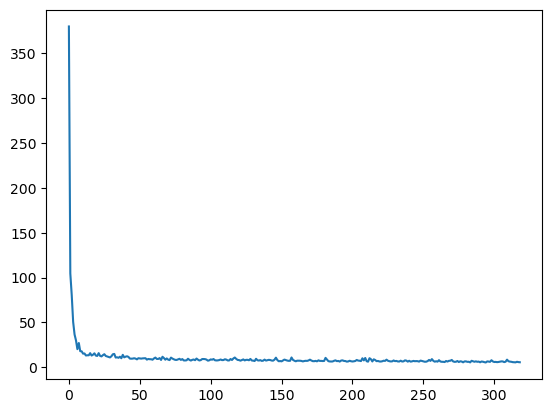

In [60]:
Loss_curve = model.loss_curve_
plt.plot(Loss_curve)
plt.show()

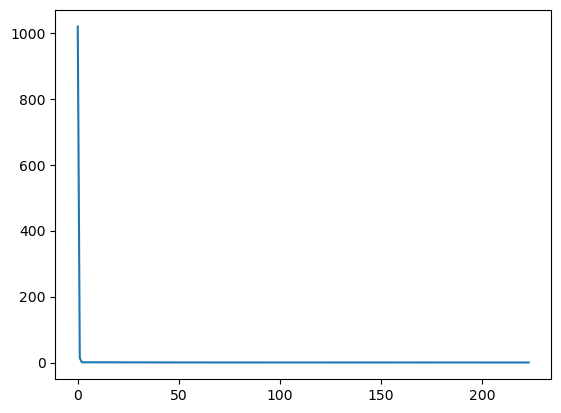

In [58]:
Loss_curve = model_scaled.loss_curve_
plt.plot(Loss_curve)
plt.show()

In [62]:
model_score = model.score(X_train, y_train)
model_score

0.8596499587330291

In [63]:
model_score_test = model.score(X_test, y_test)
model_score_test

0.7701152204798545

In [64]:
model_scaled_score = model_scaled.score(X_train, y_train_scaled)
model_scaled_score

0.8423256197252175

In [65]:
model_scaled_score = model_scaled.score(X_test, y_test_scaled)
model_scaled_score

0.6916650405991003

Evaluation

In [66]:
# Prediction
y_pred = model.predict(X_test)
y_pred

array([34.76089466, 22.85142471, 16.58564715, 20.50957703, 19.54649137,
       35.43467838, 31.10973868, 19.09927922, 15.50562329, 26.87450087,
       26.78249275, 27.07972292, 26.44441798, 19.76522282, 21.24757653,
       21.22611052, 19.41149891, 15.96742962, 22.48243636, 25.01229271,
       31.26726013, 21.37872996, 19.63389995, 17.64187907, 24.6375333 ,
       26.32537783, 12.52942491, 20.5641429 , 17.23375397, 24.97679652,
       44.59497956, 18.30066798, 31.90744508, 20.62654862, 17.28606663,
       31.65804683, 19.74226598, 20.1656032 , 23.91011642, 12.80700637,
       27.45814065, 17.64805566, 17.83155545, 25.51976619, 27.66228455,
       27.90123718, 19.99612818, 19.86075716, 12.95821042, 32.02407839,
       19.50271427, 26.20952607, 20.57835664, 15.24988383,  9.14960657,
       35.76303223, 19.22003846, 20.38609441, 14.97341011, 19.51260793,
       22.48939388, 21.93520763, 12.59299376, 17.93950945, 15.5976377 ,
       20.71574584, 13.19030222, 18.20718097, 25.63309969, 12.96

In [67]:
np.std(y_pred)

np.float64(7.260679030841747)

In [68]:
np.std(y_test)

np.float64(8.884843107491827)

In [69]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)    
rmse = np.sqrt(mse)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")

Mean Absolute Error: 2.4817749314173896
Mean Squared Error: 18.14720496525514
Root Mean Squared Error: 4.259953634167294


Evaluation of scaled-target model

In [73]:
# Prediction
y_pred_scaled = model_scaled.predict(X_test)
y_pred_scaled = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_pred_scaled

array([36.61861644, 22.72699671, 16.15169351, 21.18803478, 21.19232735,
       35.70335935, 28.10292447, 20.97503057, 16.32147066, 26.73295366,
       25.54690041, 25.14300253, 24.08943846, 22.27430792, 23.17326995,
       22.18589711, 21.37972671, 19.3345987 , 22.73499565, 24.44038832,
       21.91087306, 23.33400338, 21.24552938, 20.48245353, 24.89042049,
       24.24591169, 15.36224466, 21.47259816, 14.56838463, 24.09299074,
       47.47405488, 18.01898696, 30.50178311, 22.70702007, 18.21686942,
       31.68218989, 20.66056478, 20.55257662, 25.28468739, 15.0823585 ,
       28.86270783, 19.08376668, 19.24643176, 24.50976725, 21.77343503,
       26.96664992, 21.88552394, 16.32186728, 16.37398092, 32.95312682,
       21.8913008 , 24.19169113, 17.7467102 , 18.38031859,  9.30223335,
       36.38226708, 20.81642429, 18.81195394, 17.73447835, 20.79462713,
       25.34773577, 23.88742511, 16.34407891, 17.92953594, 18.40356142,
       22.93332937, 16.62865832, 19.55872493, 26.77160575, 15.50

In [74]:
mae = mean_absolute_error(y_test, y_pred_scaled)
mse = mean_squared_error(y_test, y_pred_scaled)    
rmse = np.sqrt(mse)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")

Mean Absolute Error: 2.880550315704893
Mean Squared Error: 24.340096451280754
Root Mean Squared Error: 4.933568328429308
